In [25]:
import numpy as np
import matplotlib.pyplot as plt
import random
from timeit import timeit

# Ciąg Fibonacciego

In [3]:
# Iteracyjnie
def fi(n):
    n = int(n)
    assert n >= 0;

    if n<2:
        return n;
    else:
        fpp = 0
        fp = 1
        for i in range(2, n+1):
            fn = fp + fpp;
            fpp = fp;
            fp = fn;
        return fn;

In [11]:
fi(3)

2

In [12]:
# Iteracyjnie
def fi2(n):
    n = int(n)
    assert n >= 0;

    if n<2:
        return n;
    else:
        fpp = 0
        fp = 1
        for i in range(2, n+1):
            fp, fpp = fp + fpp, fp; # op. dom. 
        return fp;

In [24]:
fi2(5)

5

In [15]:
# Rekurencyjnie
def fr(n):
    n = int(n)
    assert n >= 0;

    if n<2:
        return n; # op. dom.
    else:
        return fr(n-1) + fr(n-2); # zal. rek.

In [16]:
fr(2)

1

In [17]:
for n in range(9):
    print(n, fi(n), fi2(n), fr(n))

0 0 0 0
1 1 1 1
2 1 1 1
3 2 2 2
4 3 3 3
5 5 5 5
6 8 8 8
7 13 13 13
8 21 21 21


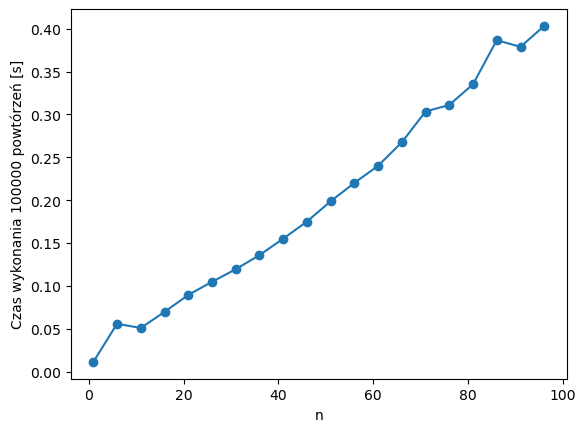

In [19]:
ns = np.arange(1, 100, 5)
times = [];
reps = 100000;

for n in ns:
    
    times.append(timeit("fi(n)", globals=globals(), number=reps))

plt.plot(ns, times, marker="o")
plt.xlabel("n");
plt.ylabel(f"Czas wykonania {reps} powtórzeń [s]");

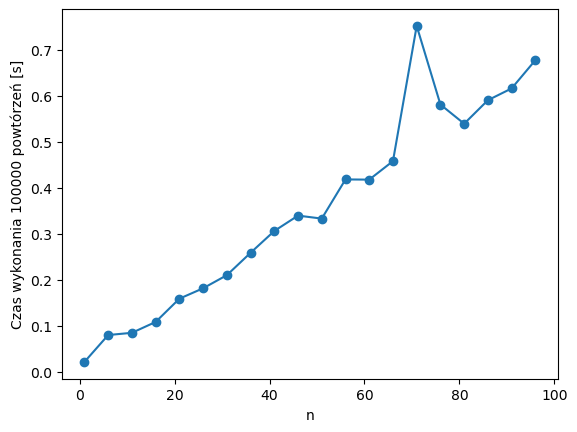

In [20]:
ns = np.arange(1, 100, 5)
times = [];
reps = 100000;

for n in ns:
    
    times.append(timeit("fi2(n)", globals=globals(), number=reps))

plt.plot(ns, times, marker="o")
plt.xlabel("n");
plt.ylabel(f"Czas wykonania {reps} powtórzeń [s]");

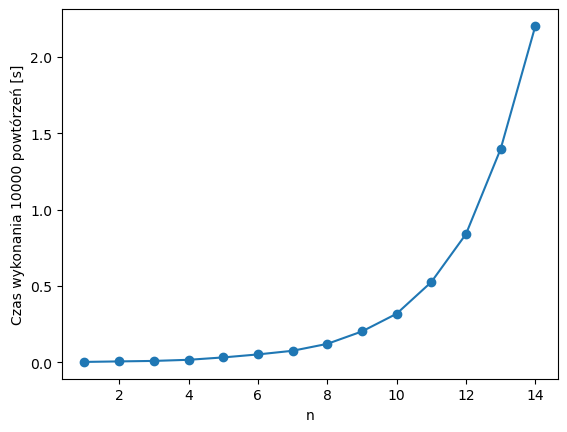

In [21]:
ns = np.arange(1, 15, 1)
times = [];
reps = 10000;

for n in ns:
    
    times.append(timeit("fr(n)", globals=globals(), number=reps))

plt.plot(ns, times, marker="o")
plt.xlabel("n");
plt.ylabel(f"Czas wykonania {reps} powtórzeń [s]");

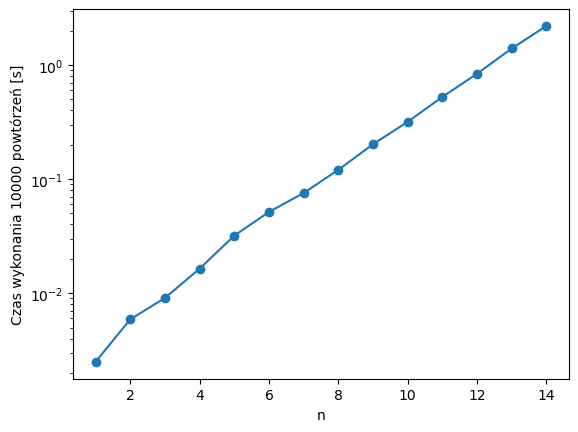

In [22]:
plt.plot(ns, times, marker="o")
plt.xlabel("n");
plt.ylabel(f"Czas wykonania {reps} powtórzeń [s]");
plt.yscale("log")

# Sortowanie

In [30]:
def z1(n):
    """
        Lista losowo poukładana.
    """
    ret = list(range(n))
    random.shuffle(ret)
    return ret;

In [29]:
z1(7)

[5, 2, 0, 3, 1, 6, 4]

In [31]:
help(z1)

Help on function z1 in module __main__:

z1(n)
    Lista losowo poukładana.



In [32]:
def z2(n):
    """
        Jeden element w złym miejscu, reszta posortowana.
    """
    ret = list(range(1,n)) + [0]
    return ret;

In [33]:
z2(8)

[1, 2, 3, 4, 5, 6, 7, 0]

## Sortowanie przez wstawianie, insertion sort

In [41]:
def insertion_sort(a):
    for i in range(1, len(a)):
        #print(a[:i+1])

        for j in reversed(range(i)):
            if(a[j] <= a[j+1]): # op. dom.
                break;
            a[j], a[j+1] = a[j+1], a[j];
            #print(a[:i+1])

        #print("-"*7)


In [42]:
t = z1(10)
print("Start:", t)
insertion_sort(t)
print("Wynik:", t)

Start: [8, 6, 3, 1, 0, 2, 7, 4, 5, 9]
Wynik: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [50]:
def test(sort_func, variant):
    times = []
    ns = []
    n = 100
    reps = 1;
    time_limit = 0.5

    while True:
        t = variant(n);
        
        time = timeit("sort_func(t)", globals=locals(), number=reps)
            
        ns.append(n)
        times.append(time)

        n = int(1.25 * n)

        print(f"{time:.3} s, {n}                    ", end = "\r", flush = True)
        if(time > time_limit) or (n > 50000000):
            break;

    plt.plot(ns, times, marker="o")

0.724 s, 5481                      

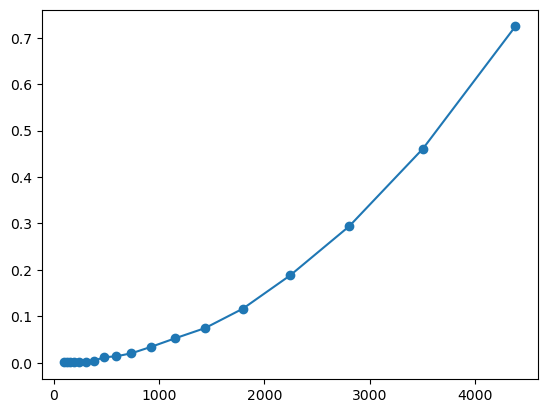

In [51]:
test(insertion_sort, z1)

0.503 s, 1450222                    

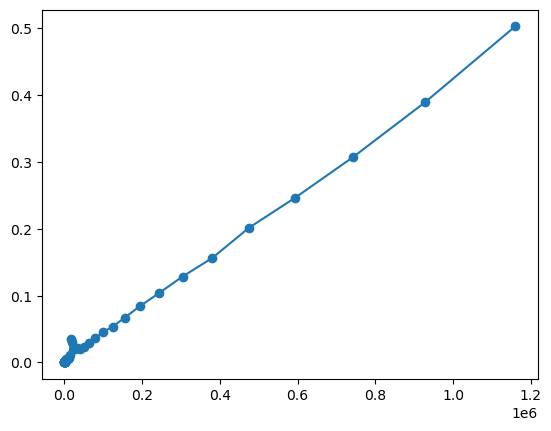

In [52]:
test(insertion_sort, z2)